<a target="_blank" href="https://colab.research.google.com/github/LSSTC-DSFP/Session-25/tree/main/Day1/SupervisedMLProblems.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# From the lecture...

```python
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Construct features and labels
X = ...
y = ...

# Separate training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Instantiate a model
clf = DecisionTreeClassifier()

# Specify hyperparameter values to test
parameters = {'max_depth': range(1, 20),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': range(1, 4)}

# Run grid search
gridsearch = GridSearchCV(clf, parameters, scoring='accuracy', cv=10)
gridsearch.fit(X_train, y_train)

# Evaluate performance
print(classification_report(y_test, gridsearch.best_estimator_.predict(X_test)))
```

# Problem 0

Load the Wisconsin Breast Cancer dataset into an X, y structure.

Establish training and testing data.

In [1]:
# This one I'll give the solution for since it will be the basis for the other
# problems we'll tackle.

from sklearn.datasets import load_breast_cancer

# let's first use a DataFrame to display the data so we can get a feel for it.
df = load_breast_cancer(as_frame=True)
df.frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
# The DataFrame was fun, but this is the solution to the problem
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Problem 1

Use the workflow from the lecture to train a `DecisionTreeClassifier` and evaluate its performance.

Print out the optimized hyperparameter settings you found.



In [3]:
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# Instantiate a model
clf = DecisionTreeClassifier()

# Specify hyperparameter values to test
parameters = {'max_depth': range(1, 20),
              'criterion': ['gini', 'entropy'],
              'min_samples_leaf': range(1, 4)}

# Run grid search
gridsearch = GridSearchCV(clf, parameters, scoring='accuracy', cv=10)
gridsearch.fit(X_train, y_train)

# Evaluate performance
print(classification_report(y_test, gridsearch.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [4]:
# print hyperparameter settings.
print(gridsearch.best_params_)

{'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 3}


# Problem 2

Choose another classifier and see if you can get higher accuracy. Use one of the following:

```python
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier  # <-- would recommend
```

For whichever one you choose, determine which hyperparameters you have available to you. To do this, take a quick look at either the scikit-learn docs or perform some introspection of the imported classes.

Heads up, the larger your grid search, the longer your runtime.

In [5]:
# Support Vector Classifier
# Docs: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#svc

from sklearn.svm import SVC

clf = SVC()
dir(clf)

# I'll choose "degree" and "kernel" as the hyperparameters to optimize.

['C',
 '__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_check_proba',
 '_compute_kernel',
 '_decision_function',
 '_dense_decision_function',
 '_dense_fit',
 '_dense_predict',
 '_dense_predict_proba',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_coef',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_impl',
 '_more_tags',
 '_parameter_constr

In [6]:
# Specify hyperparameter values to test
parameters = {'degree': range(2, 4),
              'kernel': ['poly', 'rbf', 'sigmoid']}

# Run grid search
gridsearch = GridSearchCV(clf, parameters, scoring='accuracy', cv=5)
gridsearch.fit(X_train, y_train)

# Evaluate performance
print(classification_report(y_test, gridsearch.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.95      0.83      0.89        42
           1       0.91      0.97      0.94        72

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114



In [7]:
# Nearest Neighbors Classifier
# Docs: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html#kneighborsclassifier

from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier()
dir(clf)

# I'll optimize n_neighbors and weights.

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_algorithm_metric',
 '_check_feature_names',
 '_check_n_features',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_fit',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_kneighbors_reduce_func',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_validate_data',
 '_validate_params',
 'algo

In [8]:
# Specify hyperparameter values to test
parameters = {'n_neighbors': range(2, 7),
              'weights': ['uniform', 'distance']}

# Run grid search
gridsearch = GridSearchCV(clf, parameters, scoring='accuracy', cv=5)
gridsearch.fit(X_train, y_train)

# Evaluate performance
print(classification_report(y_test, gridsearch.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87        42
           1       0.94      0.90      0.92        72

    accuracy                           0.90       114
   macro avg       0.89      0.90      0.90       114
weighted avg       0.91      0.90      0.90       114



In [9]:
# Random Forest Classifier
# Docs: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html#randomforestclassifier

from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
dir(clf)

# I'll optimize n_estimators, criterion, and max_depth.

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__sklearn_tags__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_compute_oob_predictions',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_estimators_indices',
 '_get_metadata_request',
 '_get_oob_predictions',
 '_get_param_names',
 '_get_tags',
 '_make_estimator',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_htm

In [10]:
# Specify hyperparameter values to test
parameters = {'n_estimators': [10, 20, 50, 100, 200],
              'criterion' : ['gini', 'entropy'],
              'max_depth': [None] + list(range(3, 20))}

# Run grid search
gridsearch = GridSearchCV(clf, parameters, scoring='accuracy', cv=5, n_jobs=10)
gridsearch.fit(X_train, y_train)

# Evaluate performance
print(classification_report(y_test, gridsearch.best_estimator_.predict(X_test)))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [11]:
print(gridsearch.best_estimator_)

RandomForestClassifier(criterion='entropy', max_depth=16, n_estimators=20)


## Problem 2.5

The Random Forest performed the best. Why? It's just a bunch of DecisionTreeClassifiers under the hood, so what makes it out perform?

_Hint: theres a key word in the import statement of the RFC._

The Random Forest is an ensemble classifier. It is a collection of decision trees that vote to produce a single classification.

Say the probability of one of the decision trees getting the correct classification right is 75% (so $p = 0.75$). In a forest of 9 trees, what's the probability that at least 5 of them get the classification right? This is a binomial probability problem with $n=9$ trials and success probability $p=0.75$.

The probability $P(X \ge 5)$ is given by the sum:
$$
P = \sum_{k=5}^{9} \binom{9}{k} p^{k} (1-p)^{9-k}
$$
Let's calculate this probability.

In [12]:
from scipy.special import comb

n = 9  # number of trees
p = 0.75  # probability of correct classification for one tree

probability_at_least_5 = 0
for k in range(5, n + 1):
    binomial_coefficient = comb(n, k)
    probability_k = binomial_coefficient * (p**k) * ((1 - p)**(n - k))
    probability_at_least_5 += probability_k

print(f"The probability that at least 5 out of 9 trees get the classification right is: {probability_at_least_5:.4f}")

The probability that at least 5 out of 9 trees get the classification right is: 0.9511


95% is much greater than 75%, so our ensemble classifier is doing a great job. In fact, as long as the probability of each of the ensemble members is greater than 0.5 (and they are independent), then an ensemble is guaranteed to always yield a higher probability.

# Problem 3

Let's explore the `RandomForestClassifier` a little more.

Use your trained classifer from problem 2, or if you didn't choose the RFC, train one with `criterion='entropy', max_depth=15, n_estimators=20`.

The trained classifier will have an attribute called `feature_importances_`. **Determine what the 5 most important features in the dataset are.**

Classifier introspection is a very useful tool in science / astronomy applications. Reviewers, collaborators, and (hopefully) you as a scientist, will be interested in the key drivers your classifications are based upon.

In [13]:
# Using Problem 2 result
# clf = gridsearch.best_estimator_

# Using a new classifier
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(criterion='entropy', max_depth=15, n_estimators=20)
clf.fit(X_train, y_train)


import numpy as np

# See Problem 0 for where `df` is defined.
df.feature_names[np.argsort(clf.feature_importances_)[-5:]]

array(['worst area', 'mean perimeter', 'worst concave points',
       'mean concave points', 'worst perimeter'], dtype='<U23')

## Problem 3.5

Make a pairplot of the data for the 5 most important features (or better yet, ask Gemini if working in Colab).

My prompt:
```
using matplotlib, write code for a corner plot to display the distributions of the [<REDACTED: list the features from problem 3 here>] columns of the dataset in this notebook. color the data points by their target_name.
```

Does it make sense that these features were the most important? Do you see separation between the benign and malignant populations?

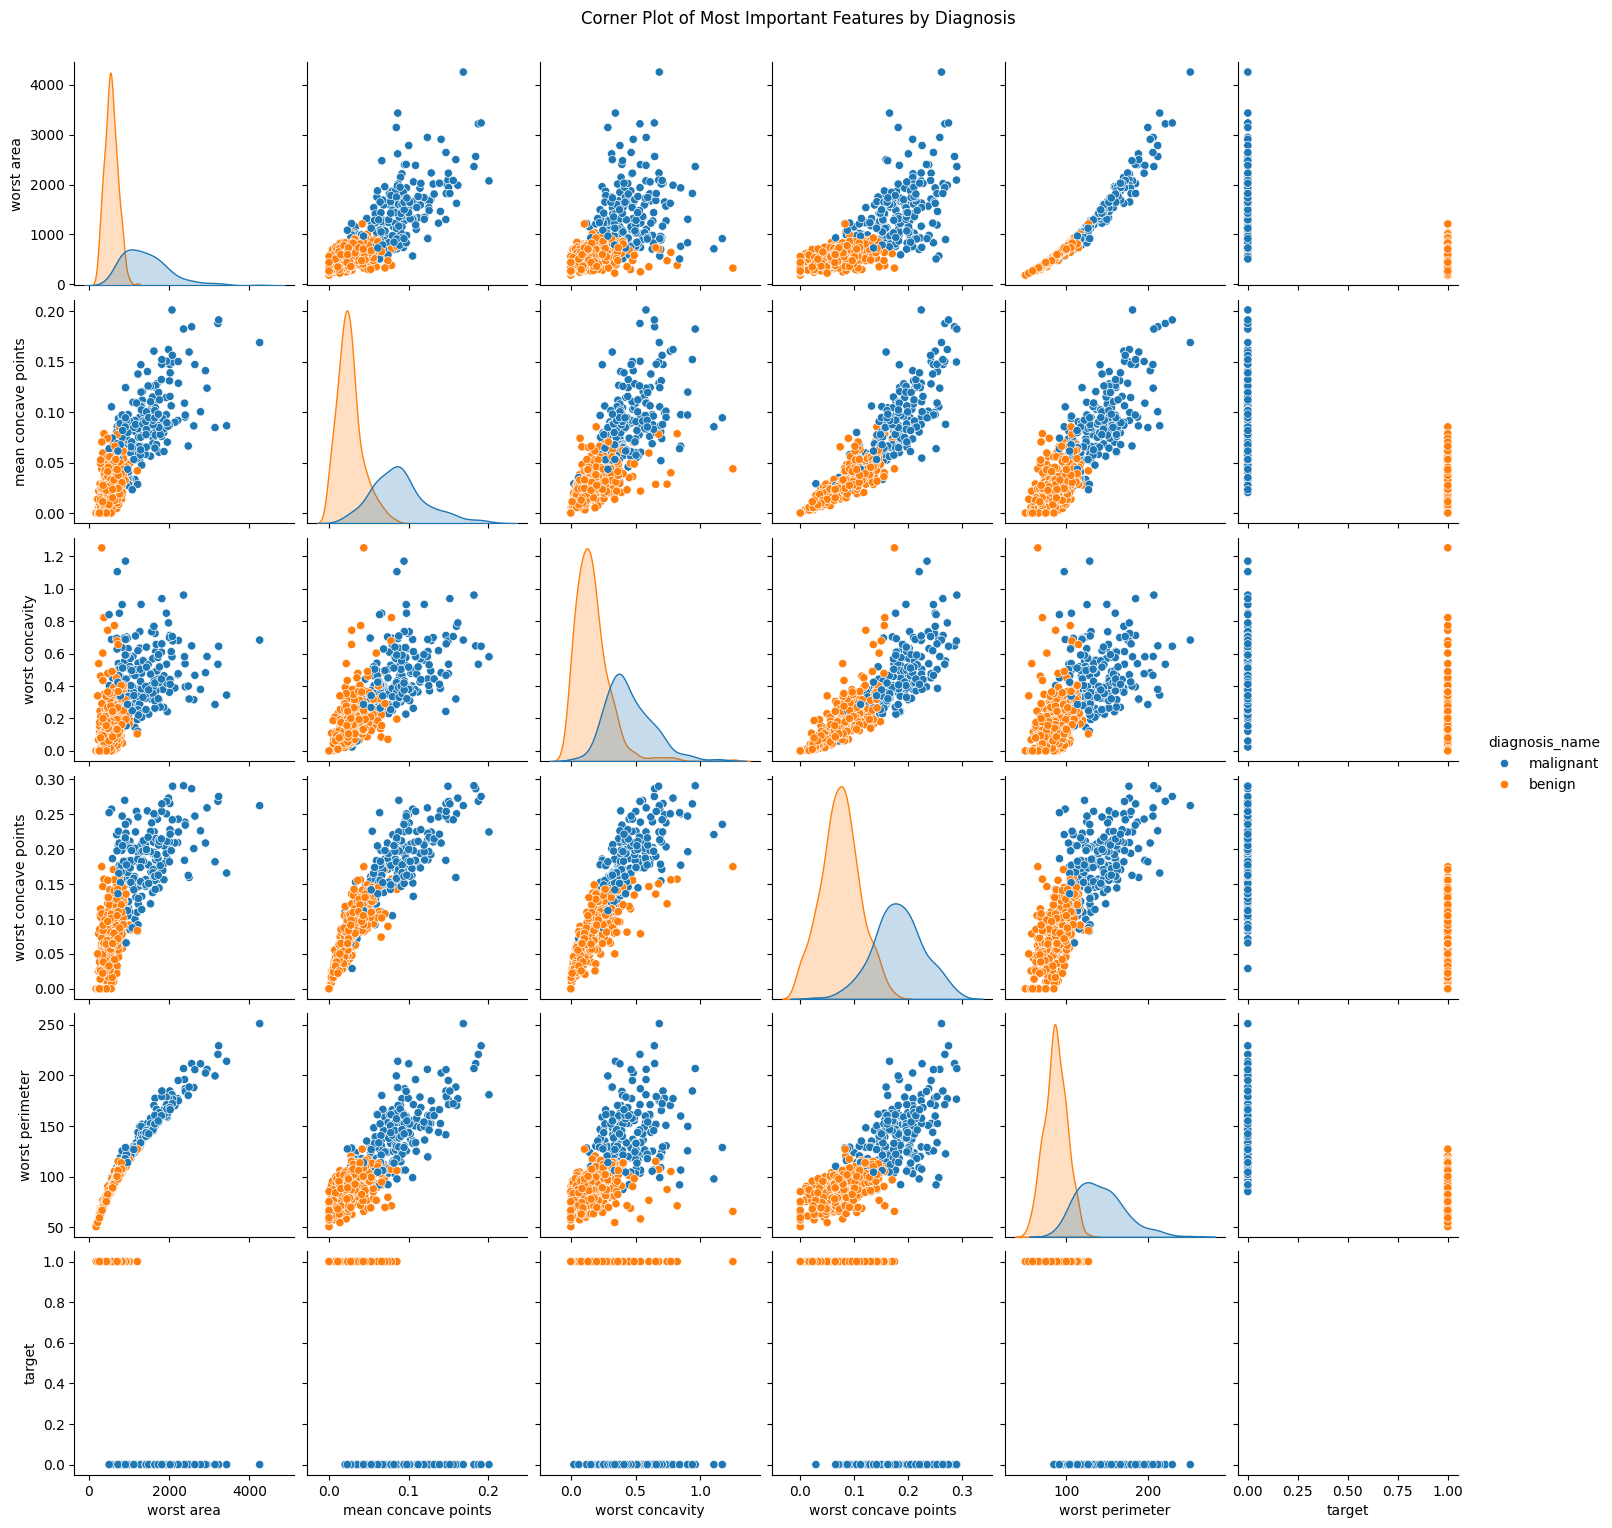

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the features for the corner plot
features = ['worst area', 'mean concave points', 'worst concavity', 'worst concave points', 'worst perimeter']

# Create a DataFrame with only the selected features and the target
plot_df = df.frame[features].copy() # Use .copy() to avoid SettingWithCopyWarning
plot_df['target'] = df.frame['target']

# Map numerical target to target names for better readability in the plot
plot_df['diagnosis_name'] = plot_df['target'].map(lambda x: df.target_names[x])

# Generate the pair plot, coloring by diagnosis_name
sns.pairplot(plot_df, hue='diagnosis_name')
plt.suptitle('Corner Plot of Most Important Features by Diagnosis', y=1.02) # Update title
plt.show()

# Problem 4

Overall goal: Plot a ROC Curve for your classifier. Add annotations to it that will make the plot publication ready.

### Step 1

Inspect the output of `clf.predict_proba(X)`


In [15]:
clf.predict_proba(X)

array([[1. , 0. ],
       [0.9, 0.1],
       [1. , 0. ],
       ...,
       [0.9, 0.1],
       [1. , 0. ],
       [0. , 1. ]])

There are two coloumns in the returned array. The first column is the probability (a statistician might get mad at me calling it a probability, but let's just treat it as such for now) of the example being the first class and the second column is the probablity of the example being the second class.

Now believe it or not, we aren't restricted to classifying examples as benign or malignant using a _probability_ threshold of 0.5. We can choose any threshold on the interval [0, 1] to make our classifications.

### Step 2

Get familiar with the Scikit-Learn `roc_curve` function.

Docs: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html#roc-curve

The `roc_curve` function from Scikit-Learn will return three things: `fpr`, `tpr`, and `thresholds`. You should interpret them as "for a given probability threshold, this is your false positive rate and true positive rate.

### Step 3

Use the `roc_curve` function to get the FPR, TPR, and thresholds arrays. Plot TPR as a function of FPR. Color by threshold if you're feeling fancy.

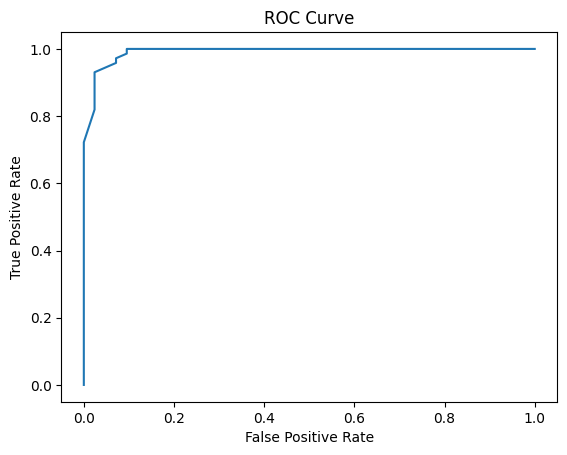

In [16]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, clf.predict_proba(X_test)[:, 1])

plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

## Problem 4.5

The ROC curve is interpretted as "the closer I can get the elbow of my curve to the point (fpr=0, tpr=1), the better my classification is."

A standard way of measuring that is by computing the area under the curve. The closer to 1.0 the AUC is, the closer you are to perfect classifications.

**Calculate the ROC AUC, and add it to your previous graph in a legend.**

Hint: Of course, Scikit-Learn has a convenient way of doing this: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#roc-auc-score

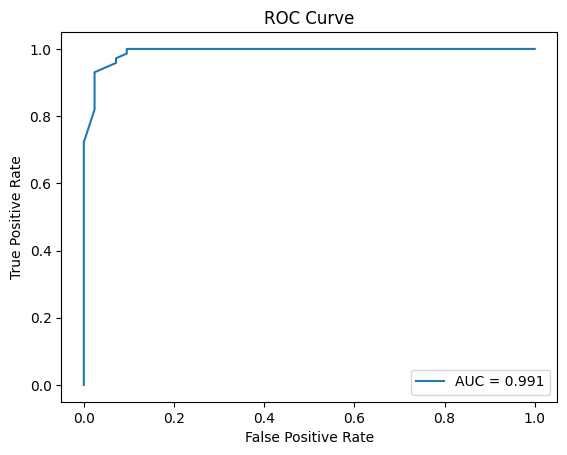

In [17]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])


plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

## Problem 4.5.5

Now what threshold should we choose? Let's think about the dataset. This is a toy problem, but one could imagine our classifications being used to make a breast cancer diagnosis for real human patients.

Would you rather prioritize a high TPR and tolerate an FPR? Would you rather prioritize a low FPR and compromise on TPR? Would you like to stay balanced and remain in the middle?

Personally, I would choose to err on the side where I classify a malignant tumor as benign as infrequently as possible, to avoid patients in need missing out on treatment. That is, at the minimum FPR for which TPR = 1.

**Choose an operating threshold, annotate your plot with a star (marker='*') at that threshold, and annotate the point with the FPR and TPR of that threshold.**

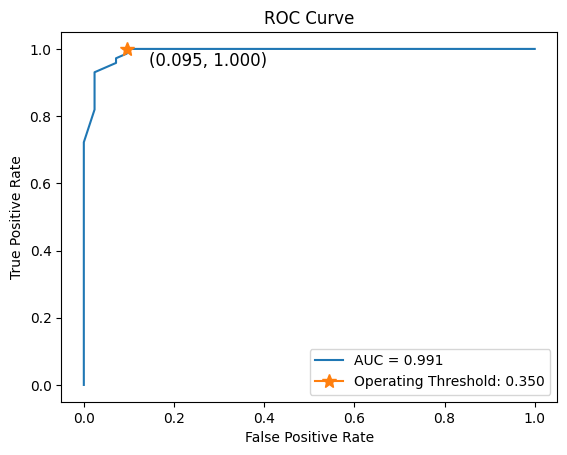

In [18]:
cond = tpr >= 0.99

op_threshold = thresholds[np.argmax(cond)]
op_tpr = tpr[np.argmax(cond)]
op_fpr = fpr[np.argmax(cond)]

plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot(op_fpr, op_tpr, marker='*', markersize=10, label=f'Operating Threshold: {op_threshold:.3f}')
plt.text(op_fpr + 0.05, op_tpr - 0.05, f'({op_fpr:.3f}, {op_tpr:.3f})', fontsize=12)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

So in my case, I will classify any example that my classifer scores a malignant probability of 0.35 or higher as malignant. I will classify malignant tumors correctly 100% of the time and misclassify benign tumors as malignant 9.5% of the time. The plot we constructed in this approach conveys all of that information.